# 0. Context
![cofac150](cofac150boxes.png)

# 1. Feature Engineering
Take the raw data and turn it into the summary statistics. We can have a set of features $F_{c} = (\mu, \sigma, P_0, P_{10}, P_{25}, P_{50}, P_{75}, P_{90}, P_{100}) \text{ for $c \in C$}$ if $C$ is the set of channels. That is to say, for each channel, we can compute a set of summary statistics, so that the number of features for a given sample are $C \cdot |F_c|$.

The given set of features is given as an example only, and may be refined at any point.

---

## Feature Discussion
> In statistics, the one in ten rule is a rule of thumb for how many predictor parameters can be estimated from data when doing regression analysis (in particular proportional hazards models in survival analysis and logistic regression) while keeping the risk of overfitting and finding spurious correlations low. The rule states that one predictive variable can be studied for every ten events.[1][2][3][4] For logistic regression the number of events is given by the size of the smallest of the outcome categories, and for survival analysis it is given by the number of uncensored events.[3] In other words: for each feature we need 10 observations/labels.
[https://en.wikipedia.org/wiki/One_in_ten_rule]

Since we have a very limited set of data, we should select the most relevant distribution statistics. The features of a distribution are its shape, spread, and center, and we must ideally characterize all of these. The center must obviously be median, but there are several ways to incorporate details for shape and spread.

1. Median — this feature characterizes the center of the distribution and is usually preferred against the mean.
2. Interquartile Range (IQR) — this feature characterizes the spread of the data, which is highly relevant for the classification problem at hand since diseased samples appear to have high spread in at least one channel.
3. 10th percentile — this feature characterizes the outlier behavior of diseased samples. From the boxplots of the samples, it appears that the diseased samples most often have outliers in the lower portion of the distribution, so this is likely more useful than the 90th percentile.

We could also incorporate some more "novel" or "unusual" features that characterize the distributions:

4. Earth Mover's Distance or Kolmogorov-Smirnov Statistic: these tests essentially characterize the difference in distributions. We could feasibly pool the set of healthy samples since they are tightly distributed, and compare this "average healthy pool" distribution to any given distribution. Then we would expect that new samples would have a low EMD or KS statistic, whereas the high variability of the diseased samples would lead to a high EMD or KS statistic.
5. some method to compare the number of peaks / compare between multiple peaks in a single channel — it may be possible to characterize the change in a peak in a diseased sample (e.g. the cancerous cell population)
---

We should also note that these distribution statistics are not the features — in fact the number of features is $C \cdot |F_c|$ as described above: the number of channels multiplied by the number of selected distribution statistics. For now (naïvely, of course) we will select the most variable channels (highly subjective!): CD45, CD5, CD22.

---

In [1]:
# relevant imports
import pandas as pd
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# load normalized data for all files (note: please delete this data after summary statistic generation!)
data_dir = "../flownorms/validation_data/CLL_102/"
labels = pd.read_csv(os.path.join(data_dir, "CLL_train.csv"))
labels['File'].to_numpy()

array(['CLL_102/13045.txt', 'CLL_102/15030.txt', 'CLL_102/15032.txt',
       'CLL_102/16329.txt', 'CLL_102/16331.txt', 'CLL_102/19303.txt',
       'CLL_102/19328.txt', 'CLL_102/20706.txt', 'CLL_102/22663.txt',
       'CLL_102/24242.txt', 'CLL_102/25494.txt', 'CLL_102/25664.txt',
       'CLL_102/29515.txt', 'CLL_102/6541.txt', 'CLL_102/13042.txt',
       'CLL_102/18714.txt', 'CLL_102/18726.txt', 'CLL_102/19074.txt',
       'CLL_102/19252.txt', 'CLL_102/19322.txt', 'CLL_102/21741.txt',
       'CLL_102/22687.txt', 'CLL_102/25424.txt', 'CLL_102/28032.txt',
       'CLL_102/28047.txt', 'CLL_102/28066.txt', 'CLL_102/28476.txt',
       'CLL_102/28707.txt', 'CLL_102/29593.txt', 'CLL_102/29881.txt',
       'CLL_102/30034.txt', 'CLL_102/30172.txt', 'CLL_102/5071.txt',
       'CLL_102/5807.txt', 'CLL_102/6535.txt', 'CLL_102/7725.txt',
       'CLL_102/7805.txt', 'CLL_102/8479.txt', 'CLL_102/8485.txt',
       'CLL_102/8604.txt', 'CLL_102/9462.txt', 'CLL_102/9531.txt',
       'CLL_102/15066.txt', 'CL

In [7]:
files = []
for file in labels['File'].to_numpy():
    file_asdf = pd.read_csv(os.path.join(data_dir, f'{file.split('/')[1]}' + '.fcs.txt'), sep='\t')
    files.append(file_asdf)

labels['raw'] = files
labels

,Index,Label,Proportion,File,raw
0,13045,0.0,0.00000,CLL_102/13045.txt,FSC-A FSC-H FSC-W ...
1,15030,0.0,0.00000,CLL_102/15030.txt,FSC-A FSC-H FSC-W ...
2,15032,0.0,0.00000,CLL_102/15032.txt,FSC-A FSC-H FSC-W ...
3,16329,0.0,0.00000,CLL_102/16329.txt,FSC-A FSC-H FSC-W ...
4,16331,0.0,0.00000,CLL_102/16331.txt,FSC-A FSC-H FSC-W ...
...,...,...,...,...,...
97,8535,1.0,0.36028,CLL_102/8535.txt,FSC-A FSC-H FSC-W ...
98,9343,1.0,0.16623,CLL_102/9343.txt,FSC-A FSC-H FSC-W ...
99,9422,1.0,0.21651,CLL_102/9422.txt,FSC-A FSC-H FSC-W ...
100,9444,1.0,0.00359,CLL_102/9444.txt,FSC-A FSC-H FSC-W ...


In [8]:
labels['raw'].to_numpy()[0]

,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,CD45,CD22,CD5,CD19,CD79b,CD3,CD81,CD10,CD43,CD38,Time
0,3031.866307,2058.903465,1507.537010,3439.037872,1973.377476,1784.106069,2705.492469,0.000000,848.277256,165.339834,1402.065020,0.000000,440.529702,2937.629193,2418.370758,1140.954208,52.500000
1,98.297712,98.132286,1025.475775,340.147252,304.535007,1143.466981,1009.351503,420.600990,400.118827,509.136266,523.036329,1340.729363,1079.984476,844.775758,770.701510,496.737125,52.599998
2,2218.417735,1876.463642,1210.311375,2063.128020,1519.472694,1390.039702,2117.396322,948.494306,737.017704,159.499353,1170.808753,0.000000,265.094146,2320.866625,2072.015109,653.062745,52.700001
3,4094.984379,2824.716454,1484.127932,4094.984379,3947.504768,1061.997618,3342.492523,1699.121700,2448.744811,1161.207756,2043.670742,3094.586094,1625.164143,3423.243809,3054.714599,1826.478699,53.000000
4,3328.614886,2296.329861,1483.963421,3743.538220,2010.540276,1906.177821,2734.301080,1446.675036,958.922659,148.867511,1480.001660,1296.326237,222.041360,2297.383735,2386.507943,1366.341004,53.400002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2640.184124,1994.778500,1354.981857,3758.358819,2788.100395,1380.014807,2667.511025,775.381117,828.954887,498.971284,1283.165719,1001.663567,922.611272,2780.028297,2510.129618,891.360899,14248.599609
99996,3252.997121,2354.659367,1414.326008,3944.517949,1987.217846,2032.087382,2840.868297,658.385327,1074.269791,408.005923,1491.371266,585.661375,411.482232,2897.531726,2478.912265,954.962989,14248.599609
99997,2104.774588,1552.167835,1388.228133,3012.275876,2010.305958,1534.004058,2602.975631,698.131227,661.709399,763.672901,1256.896551,732.855345,81.353415,2716.155872,2401.449175,727.069777,14248.700195
99998,444.775938,414.117622,1099.541184,291.570675,235.161324,1269.322233,1026.449199,1258.767002,653.647132,549.506118,1089.844949,1542.557649,1269.581698,3108.176364,1399.630567,2409.387677,14249.000000


In [10]:
dataonly = []
for dataset in labels['raw'].to_numpy():
    dropped = dataset.drop(columns=['Time'])
    # dropped = dropped.drop(columns=['FSC.A', 'FSC.H', 'FSC.W', 'SSC.A', 'SSC.H', 'SSC.W', 'CD19', 'CD79b', 'CD3', 'CD81', 'CD10', 'CD43', 'CD38'])
    dataonly.append(dropped)

labels['raw'] = dataonly

labels['raw'].to_numpy()[0]

,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,CD45,CD22,CD5,CD19,CD79b,CD3,CD81,CD10,CD43,CD38
0,3031.866307,2058.903465,1507.537010,3439.037872,1973.377476,1784.106069,2705.492469,0.000000,848.277256,165.339834,1402.065020,0.000000,440.529702,2937.629193,2418.370758,1140.954208
1,98.297712,98.132286,1025.475775,340.147252,304.535007,1143.466981,1009.351503,420.600990,400.118827,509.136266,523.036329,1340.729363,1079.984476,844.775758,770.701510,496.737125
2,2218.417735,1876.463642,1210.311375,2063.128020,1519.472694,1390.039702,2117.396322,948.494306,737.017704,159.499353,1170.808753,0.000000,265.094146,2320.866625,2072.015109,653.062745
3,4094.984379,2824.716454,1484.127932,4094.984379,3947.504768,1061.997618,3342.492523,1699.121700,2448.744811,1161.207756,2043.670742,3094.586094,1625.164143,3423.243809,3054.714599,1826.478699
4,3328.614886,2296.329861,1483.963421,3743.538220,2010.540276,1906.177821,2734.301080,1446.675036,958.922659,148.867511,1480.001660,1296.326237,222.041360,2297.383735,2386.507943,1366.341004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2640.184124,1994.778500,1354.981857,3758.358819,2788.100395,1380.014807,2667.511025,775.381117,828.954887,498.971284,1283.165719,1001.663567,922.611272,2780.028297,2510.129618,891.360899
99996,3252.997121,2354.659367,1414.326008,3944.517949,1987.217846,2032.087382,2840.868297,658.385327,1074.269791,408.005923,1491.371266,585.661375,411.482232,2897.531726,2478.912265,954.962989
99997,2104.774588,1552.167835,1388.228133,3012.275876,2010.305958,1534.004058,2602.975631,698.131227,661.709399,763.672901,1256.896551,732.855345,81.353415,2716.155872,2401.449175,727.069777
99998,444.775938,414.117622,1099.541184,291.570675,235.161324,1269.322233,1026.449199,1258.767002,653.647132,549.506118,1089.844949,1542.557649,1269.581698,3108.176364,1399.630567,2409.387677


In [11]:
features_list = []

for index, row in labels.iterrows():
    cell_data = row['raw']
    sample_id = row['File']
    label = row['Label']
    
    patient_features = {'File': sample_id, 'Label': label}
    
    for channel in cell_data.columns:
        patient_features[f'{channel}_median'] = cell_data[channel].median()
        patient_features[f'{channel}_stdev']    = cell_data[channel].std()
        patient_features[f'{channel}_iqr']    = cell_data[channel].quantile(0.75) - cell_data[channel].quantile(0.25)
        patient_features[f'{channel}_p90']    = cell_data[channel].quantile(0.90)
        patient_features[f'{channel}_p10']    = cell_data[channel].quantile(0.10)

        
    features_list.append(patient_features)

df_final = pd.DataFrame(features_list).set_index('File')

In [12]:
df_final

,Label,FSC-A_median,FSC-A_stdev,FSC-A_iqr,FSC-A_p90,FSC-A_p10,FSC-H_median,FSC-H_stdev,FSC-H_iqr,FSC-H_p90,...,CD43_median,CD43_stdev,CD43_iqr,CD43_p90,CD43_p10,CD38_median,CD38_stdev,CD38_iqr,CD38_p90,CD38_p10
File,,,,,,,,,,,,,,,,,,,,,
CLL_102/13045.txt,0.0,2591.841437,1286.173850,1744.129869,4094.984379,174.811803,1957.342329,843.654428,1127.330174,2426.801125,...,2393.075974,652.419714,468.325836,2732.704194,957.162506,1249.423573,577.551048,716.174692,2080.040015,510.540357
CLL_102/15030.txt,0.0,2570.962258,1333.071856,1853.764229,4094.984379,168.938741,1904.409943,834.754747,941.348248,2490.721453,...,2329.210373,719.316781,500.813753,2756.004949,710.102150,1463.498526,585.514504,763.518622,2212.611436,587.054485
CLL_102/15032.txt,0.0,2304.388562,1301.121588,1768.030710,4094.984379,154.415543,1766.357718,835.743953,1136.870813,2430.047207,...,2330.091551,695.186238,469.699601,2731.286341,700.023199,1430.366232,607.970201,849.314903,2249.500233,560.627492
CLL_102/16329.txt,0.0,2374.794830,1342.902788,2479.320712,4094.984379,166.862013,1790.515881,856.506081,1631.535172,2384.575499,...,2388.612965,782.954962,957.082697,2749.709162,632.645682,1435.854573,634.466234,903.763527,2273.491400,530.232892
CLL_102/16331.txt,0.0,2697.507650,1253.570793,1613.930127,4094.984379,232.313639,1986.561756,783.077412,763.911109,2497.360456,...,2375.327954,655.219575,404.232511,2846.950092,960.584725,1494.743843,598.090544,759.878067,2284.932039,620.919430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CLL_102/8535.txt,1.0,1745.714443,834.239423,719.007463,3490.079118,1464.459883,1527.556658,479.848272,466.081495,2380.217188,...,2220.588756,408.456201,542.233901,2781.144923,1825.579176,630.817069,462.669616,727.798113,1237.257895,0.000000
CLL_102/9343.txt,1.0,1802.810181,1028.003737,1559.751860,3266.532073,537.799883,1465.993567,626.283442,1069.395103,2198.011683,...,2278.651874,686.421321,562.973118,2705.501210,832.270187,1371.489750,673.403356,960.422197,2315.960550,502.600858
CLL_102/9422.txt,1.0,2288.644604,832.248039,1217.529217,3485.038113,1481.297080,1795.584955,487.744011,709.393172,2397.903494,...,2503.793201,359.509997,344.861200,2828.822267,2065.319619,1331.199724,729.259329,1123.321220,2109.269152,15.712302


In [13]:
# recall to delete all that data!
del labels
del files

# 2. Validation of Differentiability
We can quickly check whether the healthy and diseased population remain differentiable with dimensionality reduction (simplest can be PCA).

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [15]:
features = [col for col in df_final.columns if col not in ['Label']]
X = df_final[features]
y = df_final['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
var_exp = pca.explained_variance_ratio_
print("Cumulative explained variance:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.2753912  0.20913895]
Cumulative explained variance: 0.4845301513265796


In [16]:
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Status'] = y.values
pca_df['Status'] = pca_df['Status'].map({0: 'Healthy', 1: 'Cancer'})

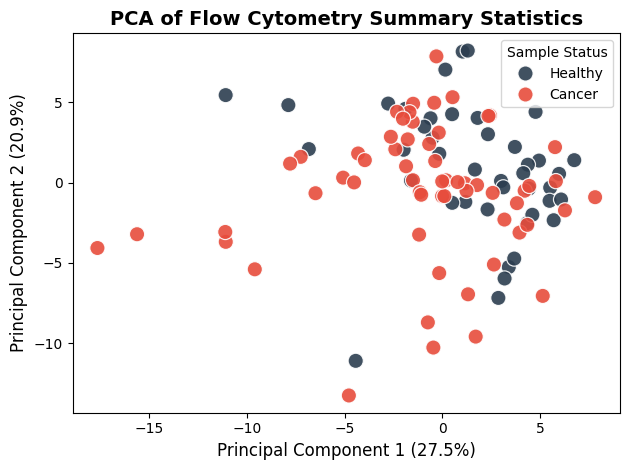

In [17]:
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Status', 
    palette={'Healthy': '#2c3e50', 'Cancer': '#e74c3c'}, # Dark Gray and Red
    data=pca_df,
    s=120, alpha=0.9, edgecolor='white'
)
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.1%})', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.1%})', fontsize=12)
plt.title('PCA of Flow Cytometry Summary Statistics', fontsize=14, fontweight='bold')
plt.legend(title='Sample Status', frameon=True)
plt.tight_layout()

Although the cancer population and the healthy population appear to mix a lot, there are some significant outliers ... I do not expect the model to be very accurate. For now, this will do. In future, it would be prudent to try different combinations of markers. In any case, it is very reassuring that the healthy samples cluster tightly.

# 3. Modeling
Since the data is pre-normalized (and in fact normalization is one of the testing cases for these models), we need not worry with further data manipulation and can simply feed it to various models.

## Logistic Regression First Pass
LR is likely going to work best for the naïve implementation, but once we implement some bagging methods it may be a better idea to use something like random forest.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(l1_ratio=1, solver='liblinear', C=1, random_state=1))
])

X = df_final.drop(columns=['Label'])
y = df_final['Label']

In [20]:
loo = LeaveOneOut()
y_pred = cross_val_predict(pipeline, X, y, cv=loo)

print("Classification Report:")
print(classification_report(y, y_pred, target_names=['Healthy', 'Cancer']))

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.68      0.81      0.74        42
      Cancer       0.85      0.73      0.79        60

    accuracy                           0.76       102
   macro avg       0.76      0.77      0.76       102
weighted avg       0.78      0.76      0.77       102



In [21]:
pipeline.fit(X, y)
model_coeffs = pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_coeffs})
significant_features = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient')

print("Features selected by the model:")
print(significant_features)

Features selected by the model:
         Feature  Coefficient
51   CD79b_stdev    -1.321911
61    CD81_stdev    -0.918375
25  SSC-W_median    -0.740429
59       CD3_p10    -0.668656
67      CD10_iqr    -0.377721
57       CD3_iqr    -0.336334
63      CD81_p90    -0.237041
58       CD3_p90    -0.162279
54     CD79b_p10    -0.160968
53     CD79b_p90    -0.101837
28     SSC-W_p90    -0.055220
40    CD5_median     0.024372
73      CD43_p90     0.066675
79      CD38_p10     0.070454
9      FSC-H_p10     0.088303
43       CD5_p90     0.088621
74      CD43_p10     0.138564
32      CD45_iqr     0.290177
11   FSC-W_stdev     0.311197
16   SSC-A_stdev     0.420712
41     CD5_stdev     0.493828
48      CD19_p90     0.524754
52     CD79b_iqr     0.723026
35   CD22_median     0.738658
46    CD19_stdev     1.147941


In [22]:
from sklearn.metrics import roc_curve, auc

y_probas = cross_val_predict(pipeline, X, y, cv=loo, method='predict_proba')
y_scores = y_probas[:, 1] 

fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

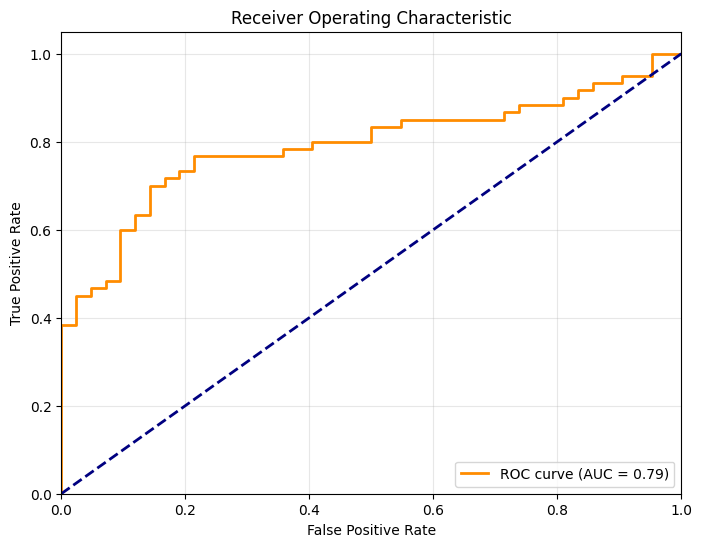

In [23]:
plt.figure(figsize=(8, 6))
lw = 2

plt.plot(
    fpr, 
    tpr, 
    color="darkorange",
    lw=lw, 
    label=f"ROC curve (AUC = {roc_auc:.2f})"
)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Logistic Regression Testing
88% accuracy is quite good on the training set — let's compare to a similarly normalized dataset from another batch "CLL_162"

In [32]:
data_dir = "../flownorms/validation_data/CLL_24/"
labels2 = pd.read_csv(os.path.join(data_dir, "CLL_test_noprop.csv"))
labels2['File'].to_numpy()

array(['CLL_24/1.fcs.txt', 'CLL_24/3.fcs.txt', 'CLL_24/5.fcs.txt',
       'CLL_24/7.fcs.txt', 'CLL_24/9.fcs.txt', 'CLL_24/11.fcs.txt',
       'CLL_24/13.fcs.txt', 'CLL_24/15.fcs.txt', 'CLL_24/17.fcs.txt',
       'CLL_24/19.fcs.txt', 'CLL_24/21.fcs.txt', 'CLL_24/23.fcs.txt',
       'CLL_24/25.fcs.txt', 'CLL_24/27.fcs.txt', 'CLL_24/29.fcs.txt',
       'CLL_24/31.fcs.txt', 'CLL_24/33.fcs.txt', 'CLL_24/35.fcs.txt',
       'CLL_24/37.fcs.txt', 'CLL_24/39.fcs.txt', 'CLL_24/41.fcs.txt',
       'CLL_24/43.fcs.txt', 'CLL_24/45.fcs.txt', 'CLL_24/47.fcs.txt'],
      dtype=object)

In [33]:
# set 2
files2 = []
for file in labels2['File'].to_numpy():
    file_asdf = pd.read_csv(os.path.join(data_dir, f'{file.split('/')[1]}'), sep='\t')
    files2.append(file_asdf)

labels2['raw'] = files2
labels2

,Index,Label,File,raw
0,1,1.0,CLL_24/1.fcs.txt,FSC-A FSC-H FSC-W ...
1,2,1.0,CLL_24/3.fcs.txt,FSC-A FSC-H FSC-W ...
2,3,1.0,CLL_24/5.fcs.txt,FSC-A FSC-H FSC-W ...
3,4,1.0,CLL_24/7.fcs.txt,FSC-A FSC-H FSC-W ...
4,5,0.0,CLL_24/9.fcs.txt,FSC-A FSC-H FSC-W ...
5,6,0.0,CLL_24/11.fcs.txt,FSC-A FSC-H FSC-W ...
6,7,1.0,CLL_24/13.fcs.txt,FSC-A FSC-H FSC-W ...
7,8,0.0,CLL_24/15.fcs.txt,FSC-A FSC-H FSC-W ...
8,9,0.0,CLL_24/17.fcs.txt,FSC-A FSC-H FSC-W ...
9,10,1.0,CLL_24/19.fcs.txt,FSC-A FSC-H FSC-W ...


In [36]:
dataonly = []
for dataset in labels2['raw'].to_numpy():
    # dropped = dataset.drop(columns=['Filename', 'batch', 'id'])
    # dropped = dropped.drop(columns=['FSC.A', 'FSC.H', 'FSC.W', 'SSC.A', 'SSC.H', 'SSC.W', 'CD19', 'CD79b', 'CD3', 'CD81', 'CD10', 'CD43', 'CD38'])
    dataonly.append(dropped)

labels2['raw'] = dataonly

labels2['raw'].to_numpy()[0]

,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,CD45,CD22,CD5,CD19,CD79b,CD3,CD81,CD10,CD43,CD38
0,2310.920048,1942.603741,1217.852258,651.688026,502.799091,1326.903021,3014.082840,1685.908990,2555.309613,2605.975582,1577.852646,1666.651129,1123.918146,1161.094462,2063.020149,619.643353
1,2174.745538,1873.245678,1188.523117,737.929661,586.450539,1288.182862,2922.215094,1530.450512,2666.698875,2467.391517,1755.257838,2058.711526,1854.612496,857.727533,2079.581265,143.306768
2,1907.010016,1591.861267,1226.427069,2091.721623,1650.565681,1297.373489,2718.322672,521.382701,1782.007708,1650.541519,1243.473448,1264.921598,864.550547,2621.759671,2420.841409,1505.103751
3,1819.843069,1601.827583,1163.086701,440.221721,354.991436,1269.543249,2847.080889,2199.442386,2249.609741,2673.312175,1227.407380,1379.423234,1461.789189,572.244847,802.887243,371.709982
4,1490.965252,1379.288177,1106.640037,249.405495,216.993885,1176.663952,2533.772992,1466.754153,1381.336090,2201.919878,1333.060509,25.980291,1356.505725,771.611022,827.512923,616.018506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1806.253981,1631.523457,1133.390096,511.109409,444.157162,1178.070103,2839.904872,2005.511410,2244.670227,2573.535395,1595.345735,1770.287468,1154.821922,969.916546,1397.735524,796.362639
99996,2089.450693,1830.927887,1168.301126,519.792134,402.682915,1321.479418,2915.671541,1877.800836,2306.937293,2334.504253,1405.430257,1644.049531,1143.465392,915.497259,1107.020671,155.093286
99997,2484.351329,2131.979370,1192.954652,703.071413,564.346561,1275.403146,2950.813985,1395.549355,2545.423802,2292.893518,1710.926038,1882.041924,1712.047149,1066.808119,2179.441744,55.062483
99998,1594.779988,1440.163937,1133.659806,330.223589,285.086632,1185.837493,2665.087146,1533.347629,2039.101100,2297.327717,1531.616189,1473.955958,1563.413631,541.035209,1844.525266,837.157137


In [38]:
features_list = []

for index, row in labels2.iterrows():
    cell_data = row['raw']
    sample_id = row['File']
    label = row['Label']
    
    patient_features = {'File': sample_id, 'Label': label}
    
    for channel in cell_data.columns:
        patient_features[f'{channel}_median'] = cell_data[channel].median()
        patient_features[f'{channel}_stdev']  = cell_data[channel].std()
        patient_features[f'{channel}_iqr']    = cell_data[channel].quantile(0.75) - cell_data[channel].quantile(0.25)
        patient_features[f'{channel}_p90']    = cell_data[channel].quantile(0.90)
        patient_features[f'{channel}_p10']    = cell_data[channel].quantile(0.10)

        
    features_list.append(patient_features)

df_validation = pd.DataFrame(features_list).set_index('File')
df_validation

,Label,FSC-A_median,FSC-A_stdev,FSC-A_iqr,FSC-A_p90,FSC-A_p10,FSC-H_median,FSC-H_stdev,FSC-H_iqr,FSC-H_p90,...,CD43_median,CD43_stdev,CD43_iqr,CD43_p90,CD43_p10,CD38_median,CD38_stdev,CD38_iqr,CD38_p90,CD38_p10
File,,,,,,,,,,,,,,,,,,,,,
CLL_24/1.fcs.txt,1.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/3.fcs.txt,1.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/5.fcs.txt,1.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/7.fcs.txt,1.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/9.fcs.txt,0.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/11.fcs.txt,0.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/13.fcs.txt,1.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/15.fcs.txt,0.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264
CLL_24/17.fcs.txt,0.0,1942.177697,436.272645,406.492379,2438.940958,1552.536996,1716.104364,309.064482,303.941402,2053.717232,...,1593.458166,590.713842,926.523561,2391.909418,812.575636,409.278054,370.891275,373.109421,807.670171,36.654264


In [39]:
del labels2
del files2

In [41]:
from sklearn.metrics import classification_report

X_new = df_validation.drop(columns=['Label'])
y_new = df_validation['Label']

y_validation_pred = pipeline.predict(X_new)

print("Validation Performance:")
print(classification_report(y_new, y_validation_pred, target_names=['Healthy', 'Cancer']))

Validation Performance:
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00         7
      Cancer       0.71      1.00      0.83        17

    accuracy                           0.71        24
   macro avg       0.35      0.50      0.41        24
weighted avg       0.50      0.71      0.59        24



/Users/isa/.pyenv/versions/flowdistml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/isa/.pyenv/versions/flowdistml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/isa/.pyenv/versions/flowdistml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

## Logistic Regression Second Pass
Since we used L1 regularization to determine the most important features in the dataset, we can then attempt to prune the set of features to these most-important features. Hopefully this makes a more robust model that is not prone to noise, and yet is still "accurate." Most commonly, the IQR and 90th percentile appear in the selected features.

```
Features selected by the model:
         Feature  Coefficient
53     CD79b_p90    -0.785748
58       CD3_p90    -0.622877
25  SSC.W_median    -0.565323
59       CD3_p10    -0.564129
63      CD81_p90    -0.432910
71    CD43_stdev    -0.344726
62      CD81_iqr    -0.339423
57       CD3_iqr    -0.305640
41     CD5_stdev    -0.238083
0   FSC.A_median    -0.216820
64      CD81_p10    -0.070086
29     SSC.W_p10    -0.052402
67      CD10_iqr    -0.019566
52     CD79b_iqr     0.028105
73      CD43_p90     0.042101
21   SSC.H_stdev     0.057191
44       CD5_p10     0.068512
50  CD79b_median     0.095406
77      CD38_iqr     0.099616
78      CD38_p90     0.119904
39      CD22_p10     0.125689
32      CD45_iqr     0.277950
11   FSC.W_stdev     0.327966
75   CD38_median     0.338671
43       CD5_p90     0.376713
3      FSC.A_p90     0.391365
45   CD19_median     0.436595
47      CD19_iqr     0.446914
48      CD19_p90     1.448850
```

## Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report

rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        random_state=1,
        class_weight='balanced'
    ))
])

loo = LeaveOneOut()
y_pred_rf = cross_val_predict(rf_pipeline, X, y, cv=loo)

print("Random Forest CV Report:")
print(classification_report(y, y_pred_rf, target_names=['Healthy', 'Cancer']))

Random Forest CV Report:
              precision    recall  f1-score   support

     Healthy       0.62      0.57      0.59        42
      Cancer       0.71      0.75      0.73        60

    accuracy                           0.68       102
   macro avg       0.66      0.66      0.66       102
weighted avg       0.67      0.68      0.67       102



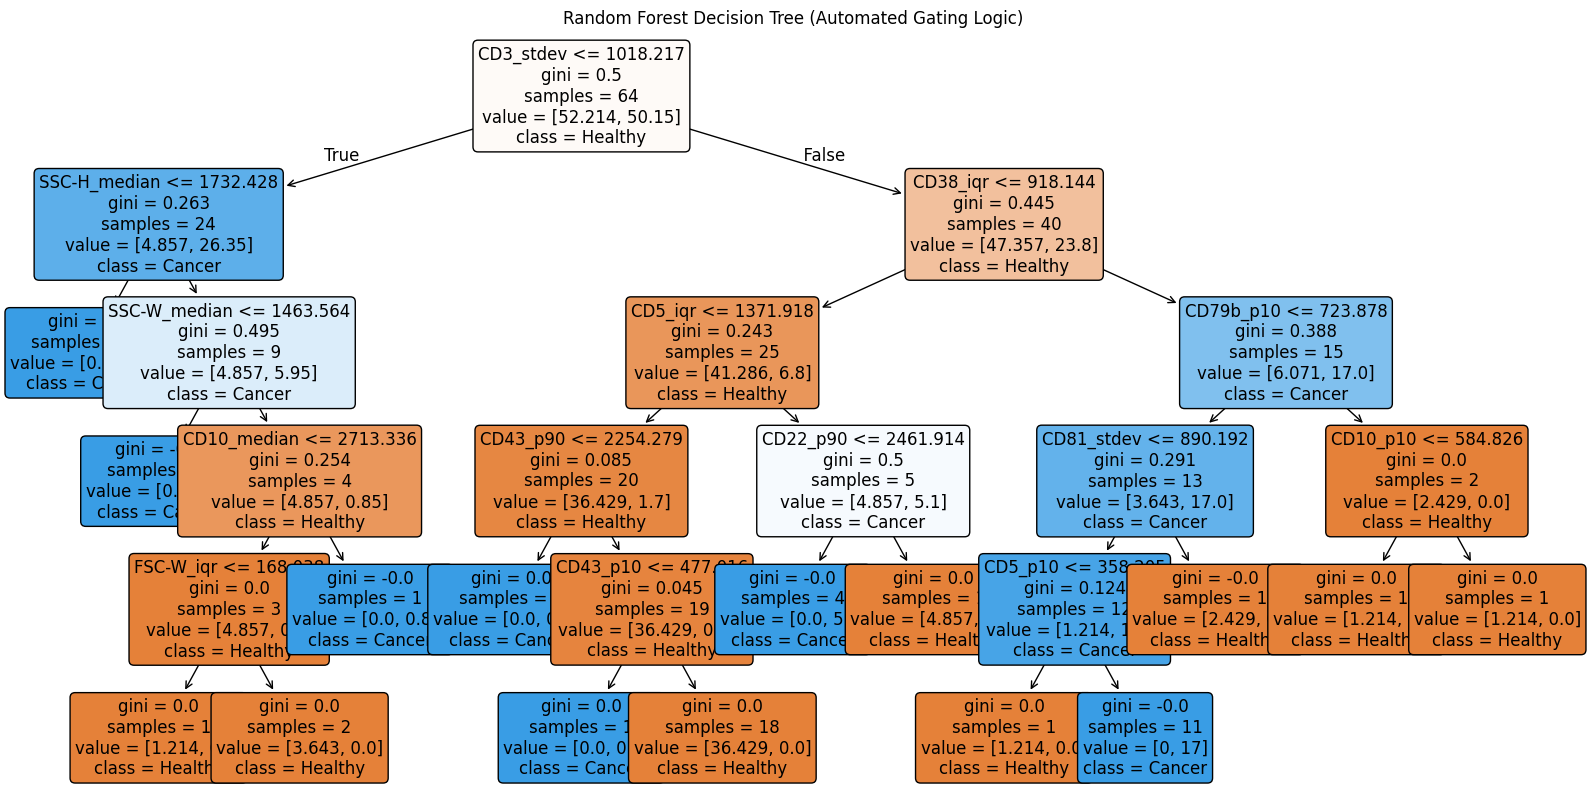

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

rf_pipeline.fit(X, y)

single_tree = rf_pipeline.named_steps['model'].estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(single_tree, 
          feature_names=X.columns, 
          class_names=['Healthy', 'Cancer'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Random Forest Decision Tree (Automated Gating Logic)")
plt.show()

In [47]:
importances = rf_pipeline.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top RF Features (Auto-Gated):")
print(feature_importance_df.head(10))

Top RF Features (Auto-Gated):
         Feature  Importance
48      CD19_p90    0.064208
65   CD10_median    0.048245
61    CD81_stdev    0.039636
25  SSC-W_median    0.036894
15  SSC-A_median    0.031156
46    CD19_stdev    0.028557
47      CD19_iqr    0.027922
56     CD3_stdev    0.026925
45   CD19_median    0.026010
63      CD81_p90    0.025594


# 4. Outputs, Plots, Conclusions (if needed)